In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [ ]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

In [ ]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:04:46  2024      1    1     0       4      46
1 2024-01-01 00:10:25  2024      1    1     0      10      25
2 2024-01-01 00:15:06  2024      1    1     0      15       6
3 2024-01-01 00:20:12  2024      1    1     0      20      12
4 2024-01-01 00:25:14  2024      1    1     0      25      14
5 2024-01-01 00:30:16  2024      1    1     0      30      16
6 2024-01-01 00:35:13  2024      1    1     0      35      13
7 2024-01-01 00:40:22  2024      1    1     0      40      22
8 2024-01-01 00:44:33  2024      1    1     0      44      33
9 2024-01-01 00:50:02  2024      1    1     0      50       2


In [ ]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 50,000 rows x 26 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [18]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0    15091
1    24941
2     9968
Name: count, dtype: int64


In [19]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 50,000 rows x 26 columns

Column types:
timestamp                           datetime64[ns]
slice_type                                   int64
latitude                                   float64
longitude                                  float64
one_way_latency_ms                         float64
jitter_ms                                  float64
rtt_ms                                     float64
packet_delay_budget_ms                     float64
handover_interruption_time_ms              float64
reliability_percent                        float64
packet_loss_percent                        float64
packet_loss_rate_percent                   float64
bler_percent                               float64
throughput_dl_mbps                         float64
throughput_ul_mbps                         float64
spectral_efficiency_bps_hz                 float64
handover_success_rate_percent              float64
energy_efficiency_bits_per_joule    

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:04:46,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024,1,1,0,4,46
1,2024-01-01 00:10:25,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024,1,1,0,10,25
2,2024-01-01 00:15:06,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal,2024,1,1,0,15,6
3,2024-01-01 00:20:12,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal,2024,1,1,0,20,12
4,2024-01-01 00:25:14,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024,1,1,0,25,14


In [20]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 50,000 rows x 26 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [21]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 23 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(47524), 1: np.int64(2476)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(319), 1: np.int64(280), 2: np.int64(316), 3: np.int

In [22]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (50000, 23)  (23 features)
  y1 shape: (50000,)  (binary)
  y2 shape: (50000,)  (multi-class, 9 classes)

  X dtypes:
slice_type                            int64
latitude                            float64
longitude                           float64
one_way_latency_ms                  float64
jitter_ms                           float64
rtt_ms                              float64
packet_delay_budget_ms              float64
handover_interruption_time_ms       float64
reliability_percent                 float64
packet_loss_percent                 float64
packet_loss_rate_percent            float64
bler_percent                        float64
throughput_dl_mbps                  float64
throughput_ul_mbps                  float64
spectral_efficiency_bps_hz          float64
handover_success_rate_percent       float64
energy_efficiency_bits_per_joule    float64
year                                  int32
month                                 int32
day        

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
0,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,2024,1,1,0,4,46
1,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,2024,1,1,0,10,25
2,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,2024,1,1,0,15,6
3,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,2024,1,1,0,20,12
4,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,2024,1,1,0,25,14


In [23]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y1_train distribution:
    Normal (0):  38,019 (95.05%)
    Anomaly (1): 1,981 (4.95%)

  y1_test distribution:
    Normal (0):  9,505 (95.05%)
    Anomaly (1): 495 (4.95%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y2_train distribution:
    backhaul_issue (0): 255 (0.64%)
    handover_failure (1): 224 (0.56%)
    hardware_failure (2): 253 (0.63%)
    interference (3): 247 (0.62%)
    network_congestion (4): 249 (0.62%)
    normal (5): 38,019 (95.05%)
    overload (6): 249 (0.62%)
    security_attack (7): 249 (0.62%)
    signal_degradation (8): 255 (0.64%)

  y2_test distribution:
    backhaul_issue (0): 64 (0.64%)
    handover_failure (1): 56 (0.56%)
    hardware_failure (2): 63 (0.63%)
    interference (3): 62 (0.62%)
    network_congestion (4): 62 (0.62%)
    normal (5): 9,505 (95.05%)
    overload (6): 62 (0.62%)
    security_at

## 4. Standardization (StandardScaler)

In [24]:
# =====================================================================
# 4.1 Apply StandardScaler
# =====================================================================
# Fit on training data ONLY, then transform both train and test sets
# This prevents data leakage from test set into training

scaler = StandardScaler()

# --- Binary classification sets ---
X_train_b_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_scaled = pd.DataFrame(
    scaler.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# --- Multi-class classification sets ---
scaler_m = StandardScaler()

X_train_m_scaled = pd.DataFrame(
    scaler_m.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_scaled = pd.DataFrame(
    scaler_m.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 4.2 Verification
# =====================================================================
print("="*70)
print("STANDARDIZATION - StandardScaler")
print("="*70)

print("--- Binary classification sets ---")
print(f"  X_train_b_scaled: {X_train_b_scaled.shape}")
print(f"  X_test_b_scaled:  {X_test_b_scaled.shape}")

print(" Train set statistics (mean ~ 0, std ~ 1):")
train_stats = pd.DataFrame({
    "Mean": X_train_b_scaled.mean().round(6),
    "Std": X_train_b_scaled.std().round(6)
})
print(train_stats)

print("Test set statistics:")
test_stats = pd.DataFrame({
    "Mean": X_test_b_scaled.mean().round(6),
    "Std": X_test_b_scaled.std().round(6)
})
print(test_stats)

print("--- Multi-class classification sets ---")
print(f"  X_train_m_scaled: {X_train_m_scaled.shape}")
print(f"  X_test_m_scaled:  {X_test_m_scaled.shape}")

print("Preview (X_train_b_scaled):")
X_train_b_scaled.head()

STANDARDIZATION - StandardScaler
--- Binary classification sets ---
  X_train_b_scaled: (40000, 23)
  X_test_b_scaled:  (10000, 23)
 Train set statistics (mean ~ 0, std ~ 1):
                                  Mean       Std
slice_type                        -0.0  1.000013
latitude                          -0.0  1.000013
longitude                         -0.0  1.000013
one_way_latency_ms                -0.0  1.000013
jitter_ms                         -0.0  1.000013
rtt_ms                            -0.0  1.000013
packet_delay_budget_ms             0.0  1.000013
handover_interruption_time_ms     -0.0  1.000013
reliability_percent               -0.0  1.000013
packet_loss_percent               -0.0  1.000013
packet_loss_rate_percent           0.0  1.000013
bler_percent                       0.0  1.000013
throughput_dl_mbps                -0.0  1.000013
throughput_ul_mbps                 0.0  1.000013
spectral_efficiency_bps_hz        -0.0  1.000013
handover_success_rate_percent      0.0  1

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
4210,0.148606,0.393241,-0.156627,-0.122978,-0.421797,-0.195227,0.226206,0.214459,0.199133,-0.141457,-0.241672,-0.270992,1.240259,1.569072,0.092905,0.092991,-0.540093,0.0,-1.436921,-0.021903,0.361913,1.412759,0.319115
16490,0.148606,1.078479,0.504794,-0.189540,-0.362939,-0.174399,0.893923,0.695093,0.225371,-0.166524,-0.245761,0.113520,-0.369201,0.907413,0.504506,-0.031747,-0.456819,0.0,-0.833572,1.365270,-0.793609,-0.890754,0.319115
48168,0.148606,-1.157168,0.986975,-0.119315,-0.003604,-0.126351,0.934000,0.190384,0.282801,-0.149786,-0.217704,-0.008151,0.557764,0.801354,0.366097,0.083448,-0.561125,0.0,1.579824,0.093695,-0.793609,-1.409044,-0.611877
9745,-1.278927,0.608440,-1.445086,-0.241066,-0.616916,-0.302687,-1.356240,-0.682123,0.453759,-0.338310,-0.334421,-0.772825,-0.833825,-0.834950,-0.314870,-0.016141,0.819934,0.0,-0.833572,-1.409076,1.228555,-1.121105,-1.484682
32778,0.148606,1.209304,-1.327061,-0.191107,-0.174753,-0.165265,0.494451,0.099591,0.194546,-0.229155,-0.238315,0.533141,1.099516,0.501243,0.527914,-0.052044,-0.424517,0.0,0.373126,0.902879,1.084115,0.318590,-1.659243


## 5. Distribution des Features apres Standardisation

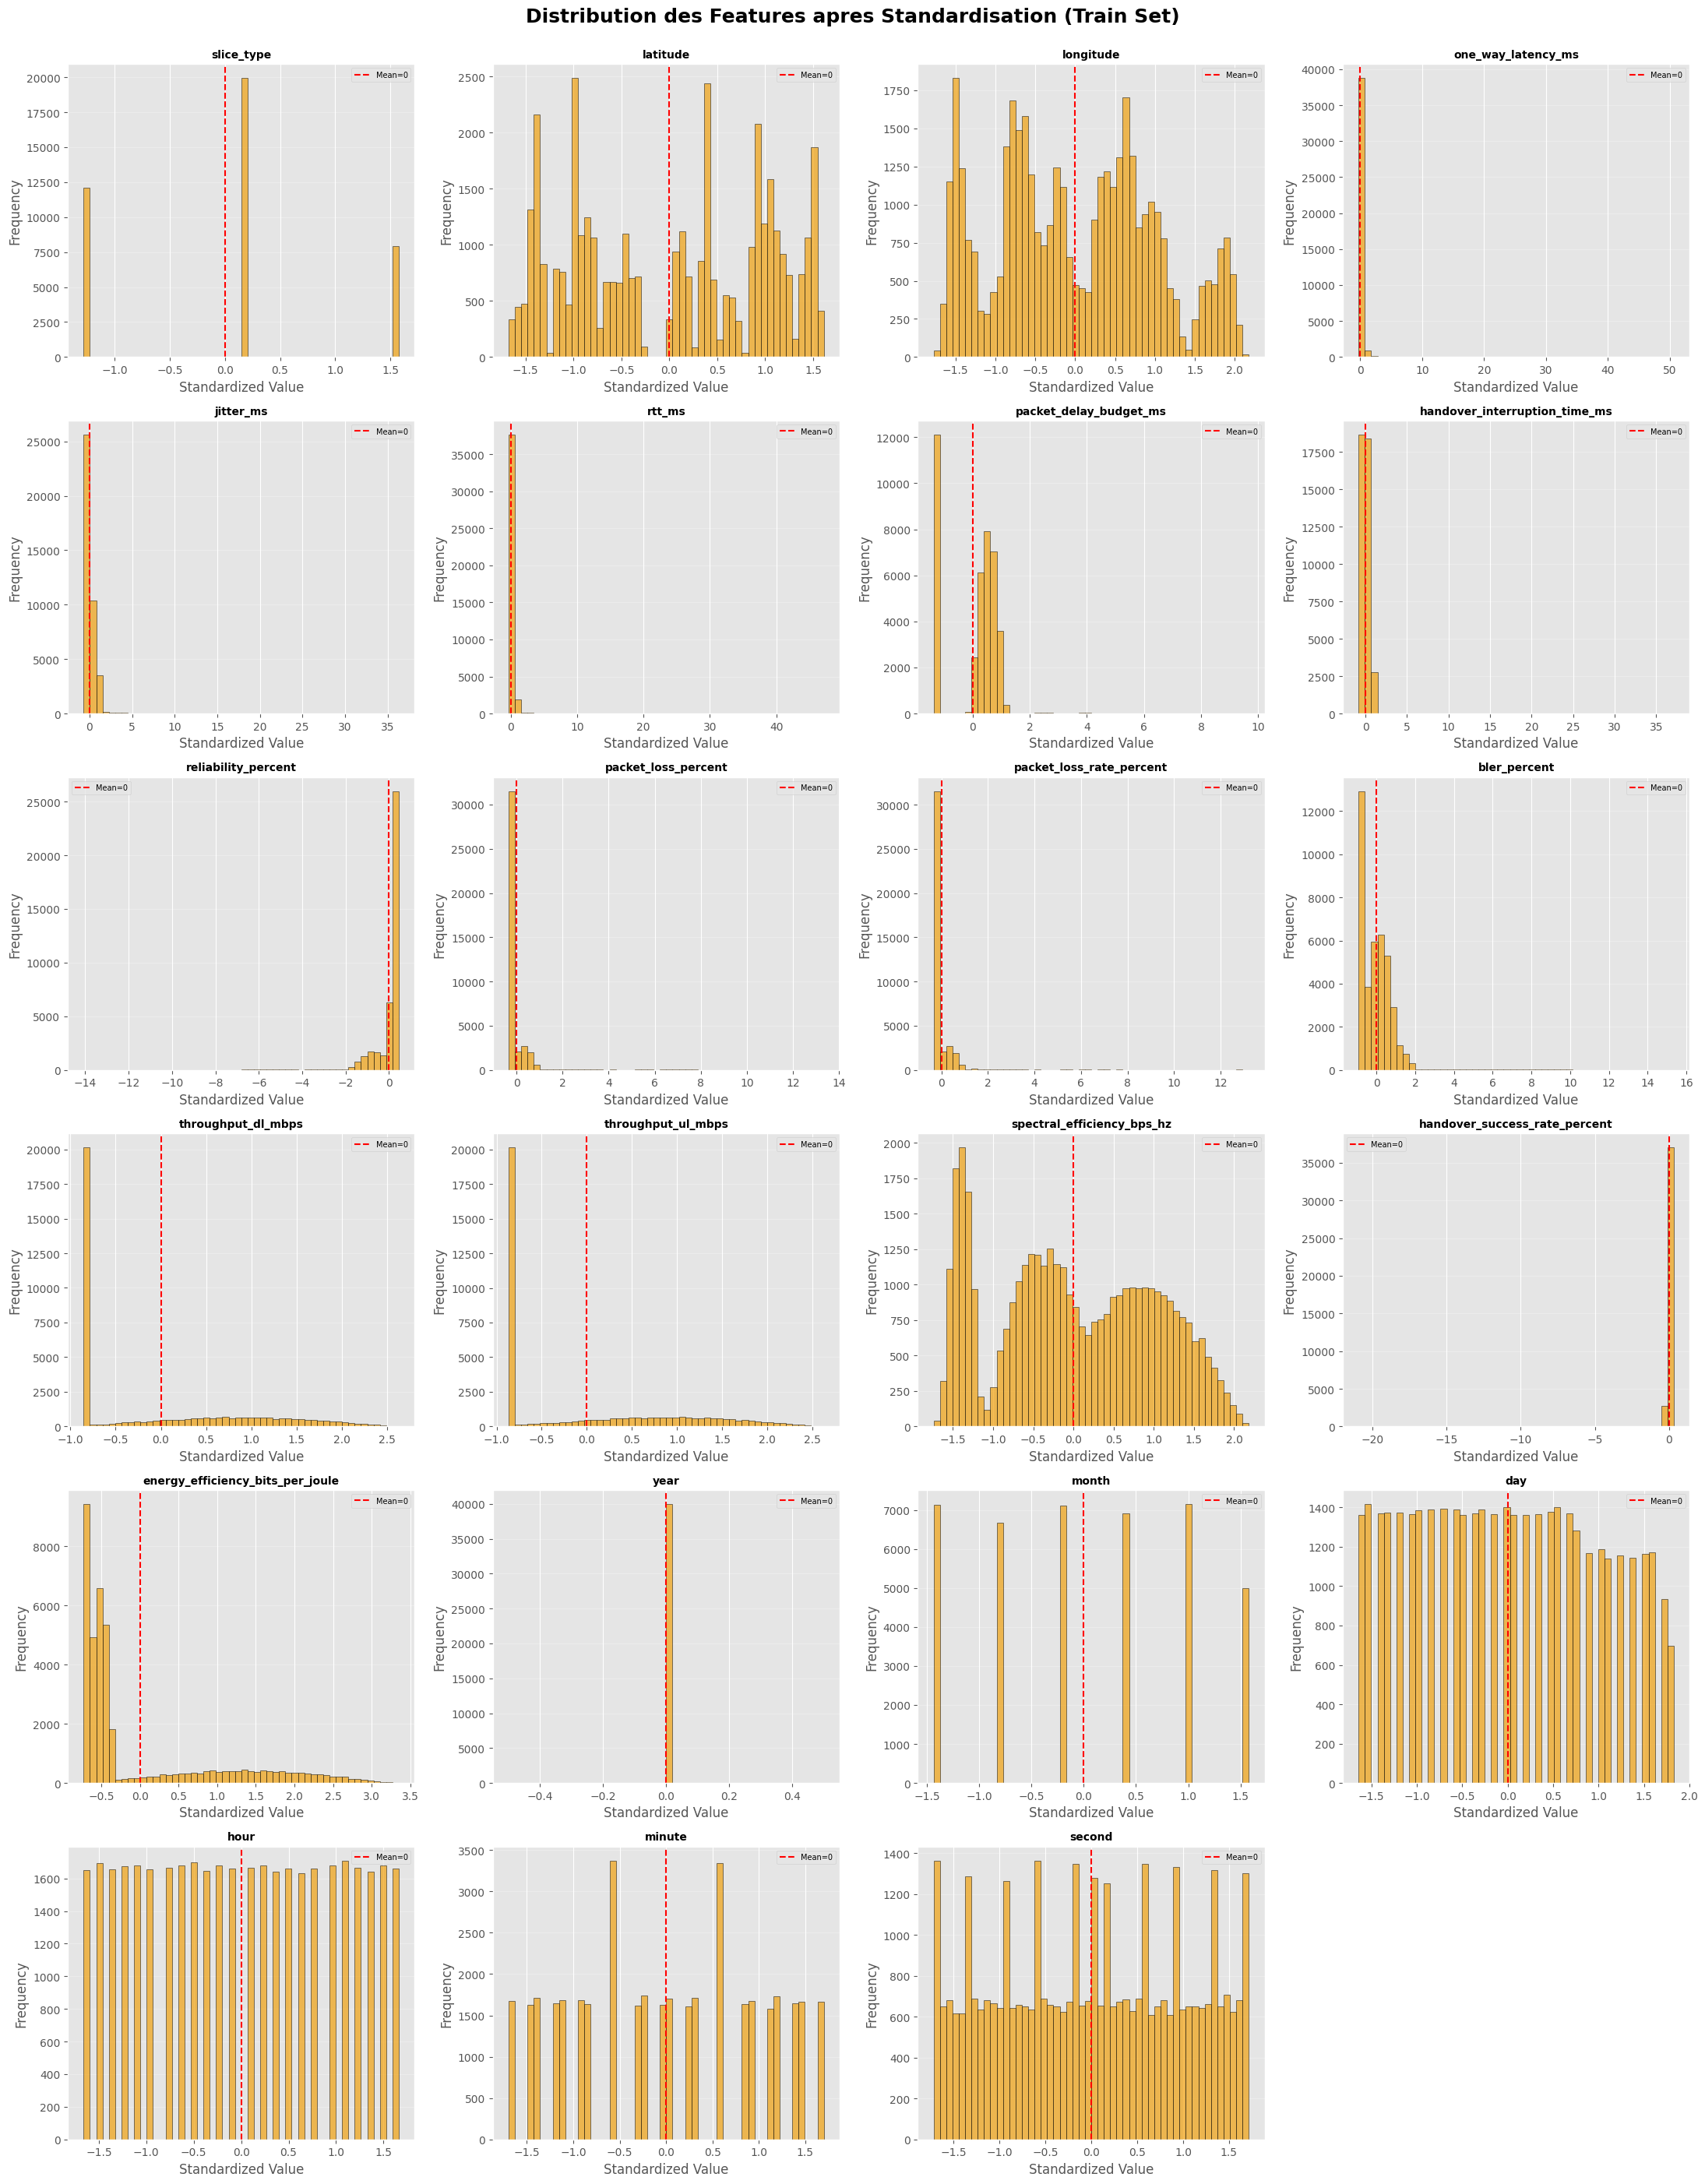

All 23 features are standardized (mean ~ 0, std ~ 1)


In [25]:
# =====================================================================
# 5. Distribution des Features apres Standardisation
# =====================================================================

fig, axes = plt.subplots(6, 4, figsize=(22, 28))
axes = axes.ravel()

for idx, col in enumerate(X_train_b_scaled.columns):
    axes[idx].hist(X_train_b_scaled[col], bins=50, color="#f0a10f",
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean=0')
    axes[idx].set_xlabel('Standardized Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplot (24 subplots, 23 features)
axes[-1].set_visible(False)

plt.suptitle('Distribution des Features apres Standardisation (Train Set)',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"All {X_train_b_scaled.shape[1]} features are standardized (mean ~ 0, std ~ 1)")

## 5.bis Comparaison des Transformations : Yeo-Johnson vs Quantile Transformer

StandardScaler ne change pas la forme de la distribution (seulement mean=0, std=1).
Pour rapprocher les distributions d'une loi normale, on compare deux approches :
- **Yeo-Johnson (PowerTransformer)** : trouve automatiquement le lambda optimal par feature
- **QuantileTransformer (Gaussian)** : force une distribution normale parfaite

In [26]:
# =====================================================================
# 5.bis.1 Apply Yeo-Johnson and Quantile Transformers
# =====================================================================
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# --- Yeo-Johnson PowerTransformer ---
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_b_yeojohnson = pd.DataFrame(
    pt_yj.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

# --- Quantile Transformer (Gaussian output) ---
qt_gauss = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
X_train_b_quantile = pd.DataFrame(
    qt_gauss.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

print("="*70)
print("TRANSFORMATIONS APPLIED")
print("="*70)
print(f"\n1. Yeo-Johnson (PowerTransformer):")
print(f"   Shape: {X_train_b_yeojohnson.shape}")
print(f"   Mean range: [{X_train_b_yeojohnson.mean().min():.6f}, {X_train_b_yeojohnson.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_yeojohnson.std().min():.4f}, {X_train_b_yeojohnson.std().max():.4f}]")

print(f"\n2. Quantile Transformer (Gaussian):")
print(f"   Shape: {X_train_b_quantile.shape}")
print(f"   Mean range: [{X_train_b_quantile.mean().min():.6f}, {X_train_b_quantile.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_quantile.std().min():.4f}, {X_train_b_quantile.std().max():.4f}]")

TRANSFORMATIONS APPLIED

1. Yeo-Johnson (PowerTransformer):
   Shape: (40000, 23)
   Mean range: [-0.000000, 0.000000]
   Std range:  [0.0000, 1.0000]

2. Quantile Transformer (Gaussian):
   Shape: (40000, 23)
   Mean range: [-5.199338, 0.012934]
   Std range:  [0.0000, 3.6523]


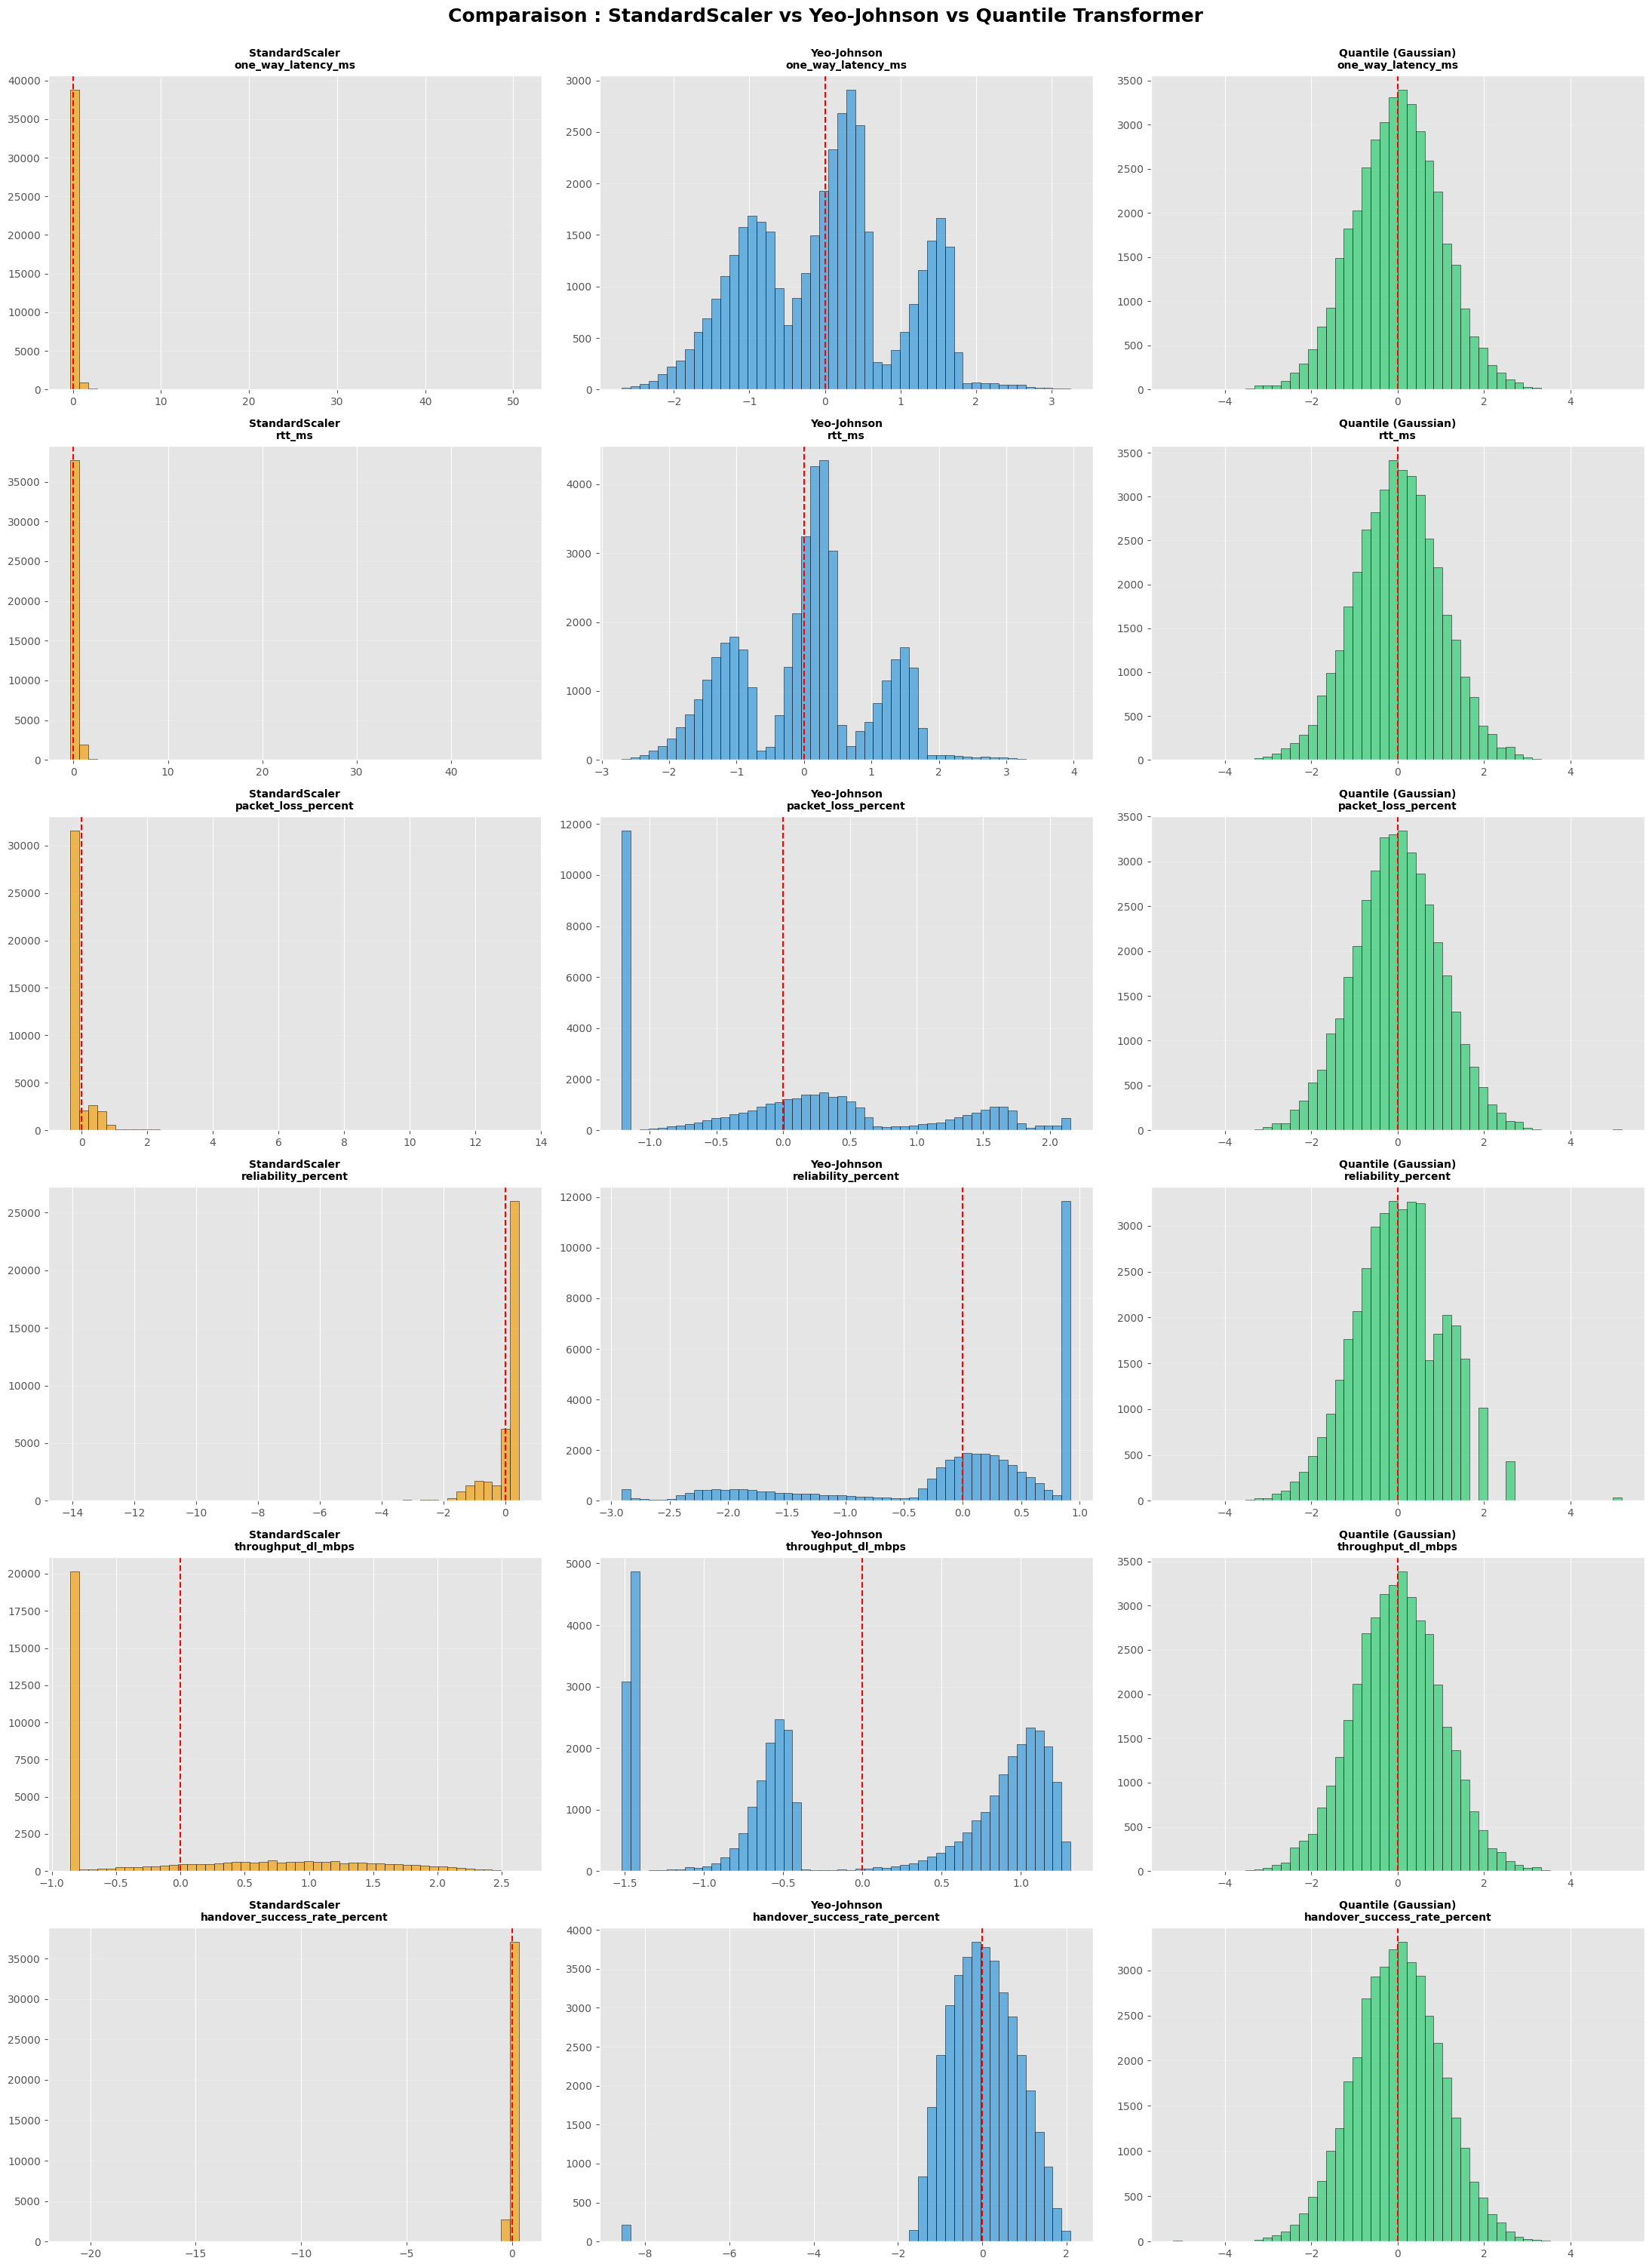

SHAPIRO-WILK COMPARISON (sample=5000)

Feature                                   StandardScaler     Yeo-Johnson        Quantile
---------------------------------------------------------------------------------------
slice_type                                      0.8032        0.7995        0.8033 *
latitude                                        0.9211        0.9211        0.9998 *
longitude                                       0.9626        0.9156        0.9994 *
one_way_latency_ms                              0.1375        0.9801        0.9997 *
jitter_ms                                       0.4319        0.9280        0.9992 *
rtt_ms                                          0.2081        0.9734        0.9994 *
packet_delay_budget_ms                          0.7622        0.7412        0.9992 *
handover_interruption_time_ms                   0.3482        0.9098        0.9994 *
reliability_percent                             0.3879        0.8235        0.9949 *
packet_loss_percent

In [27]:
# =====================================================================
# 5.bis.2 Visual Comparison: StandardScaler vs Yeo-Johnson vs Quantile
# =====================================================================
# Select 6 representative features (most skewed ones from Shapiro-Wilk)
features_to_compare = [
    'one_way_latency_ms', 'rtt_ms', 'packet_loss_percent',
    'reliability_percent', 'throughput_dl_mbps', 'handover_success_rate_percent'
]

fig, axes = plt.subplots(len(features_to_compare), 3, figsize=(22, 5 * len(features_to_compare)))

for row, feat in enumerate(features_to_compare):
    # Column 1: StandardScaler
    axes[row, 0].hist(X_train_b_scaled[feat], bins=50, color="#f0a10f", alpha=0.7, edgecolor='black')
    axes[row, 0].set_title(f'StandardScaler\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 0].grid(axis='y', alpha=0.3)

    # Column 2: Yeo-Johnson
    axes[row, 1].hist(X_train_b_yeojohnson[feat], bins=50, color="#3498db", alpha=0.7, edgecolor='black')
    axes[row, 1].set_title(f'Yeo-Johnson\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].grid(axis='y', alpha=0.3)

    # Column 3: Quantile Transformer
    axes[row, 2].hist(X_train_b_quantile[feat], bins=50, color="#2ecc71", alpha=0.7, edgecolor='black')
    axes[row, 2].set_title(f'Quantile (Gaussian)\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 2].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison : StandardScaler vs Yeo-Johnson vs Quantile Transformer',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# =====================================================================
# Shapiro-Wilk comparison on a sample
# =====================================================================
from scipy import stats

print("="*80)
print("SHAPIRO-WILK COMPARISON (sample=5000)")
print("="*80)
print(f"\n{'Feature':<40} {'StandardScaler':>15} {'Yeo-Johnson':>15} {'Quantile':>15}")
print("-" * 87)

sample_size = 5000
for feat in X_train_b_scaled.columns:
    w_std, _ = stats.shapiro(X_train_b_scaled[feat].sample(sample_size, random_state=42))
    w_yj, _ = stats.shapiro(X_train_b_yeojohnson[feat].sample(sample_size, random_state=42))
    w_qt, _ = stats.shapiro(X_train_b_quantile[feat].sample(sample_size, random_state=42))
    
    # Mark the best W statistic (closest to 1)
    best = max(w_std, w_yj, w_qt)
    mark_std = " *" if w_std == best else ""
    mark_yj = " *" if w_yj == best else ""
    mark_qt = " *" if w_qt == best else ""
    
    print(f"{feat:<40} {w_std:>13.4f}{mark_std} {w_yj:>13.4f}{mark_yj} {w_qt:>13.4f}{mark_qt}")

print("\n* = best W statistic (closest to 1 = most normal)")
print("\nConclusion:")
print("   Yeo-Johnson: recommended for most ML models (natural normalization)")
print("   Quantile: forces perfect Gaussian but may distort feature relationships")

# =====================================================================
# MODELISATION with QUANTILE TRANSFORMER
# =====================================================================
Après comparaison, nous utilisons le **QuantileTransformer (Gaussian)** pour normaliser les features avant l'entraînement des modèles. Cette approche force une distribution normale parfaite sur chaque feature.

## Step 6: QuantileTransformer — Préparation des jeux de données

In [28]:
# =====================================================================
# 6.1 Apply QuantileTransformer to Binary Classification Sets
# =====================================================================
from sklearn.preprocessing import QuantileTransformer

# Fit on training data ONLY, then transform both train and test
qt_binary = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_b_qt = pd.DataFrame(
    qt_binary.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_qt = pd.DataFrame(
    qt_binary.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# =====================================================================
# 6.2 Apply QuantileTransformer to Multi-class Classification Sets
# =====================================================================
qt_multi = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_m_qt = pd.DataFrame(
    qt_multi.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_qt = pd.DataFrame(
    qt_multi.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 6.3 Verification
# =====================================================================
print("="*70)
print("QUANTILE TRANSFORMER - DATASETS READY")
print("="*70)

print("\n--- Binary Classification ---")
print(f"  X_train_b_qt: {X_train_b_qt.shape}")
print(f"  X_test_b_qt:  {X_test_b_qt.shape}")
print(f"  Train mean range: [{X_train_b_qt.mean().min():.4f}, {X_train_b_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_b_qt.std().min():.4f}, {X_train_b_qt.std().max():.4f}]")

print("\n--- Multi-class Classification ---")
print(f"  X_train_m_qt: {X_train_m_qt.shape}")
print(f"  X_test_m_qt:  {X_test_m_qt.shape}")
print(f"  Train mean range: [{X_train_m_qt.mean().min():.4f}, {X_train_m_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_m_qt.std().min():.4f}, {X_train_m_qt.std().max():.4f}]")

print("\nPreview (X_train_b_qt):")
X_train_b_qt.head()

QUANTILE TRANSFORMER - DATASETS READY

--- Binary Classification ---
  X_train_b_qt: (40000, 23)
  X_test_b_qt:  (10000, 23)
  Train mean range: [-5.1993, 0.0129]
  Train std range:  [0.0000, 3.6523]

--- Multi-class Classification ---
  X_train_m_qt: (40000, 23)
  X_test_m_qt:  (10000, 23)
  Train mean range: [-5.1993, 0.0111]
  Train std range:  [0.0000, 3.6537]

Preview (X_train_b_qt):


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
4210,0.128317,0.225278,-0.037144,0.323466,-0.465531,-0.333163,-0.281341,0.382720,-0.222444,0.549321,-0.206203,-0.202718,0.980291,1.325021,0.119043,0.204798,-0.219350,-5.199338,-5.199338,-0.017565,0.274391,1.275302,0.256198
16490,0.128317,0.904192,0.399490,-0.228350,-0.405637,-0.160182,1.446152,1.447454,-0.104879,0.373776,-0.233454,0.245023,0.076912,0.739183,0.370566,-0.815054,0.208185,-5.199338,-0.639462,1.176890,-0.621099,-0.749670,0.256198
48168,0.128317,-1.012200,0.971745,0.353858,0.243072,0.319487,1.586899,0.342552,0.160829,0.494136,-0.025527,0.089518,0.474602,0.654709,0.276196,0.126069,-0.330443,-5.199338,5.199338,0.064027,-0.621099,-1.289578,-0.469603
9745,-5.199338,0.385859,-1.323439,-0.747274,-0.857291,-2.236892,-0.606359,-1.216679,0.849874,-1.218002,-1.544846,-0.613934,-0.285300,-0.473569,-0.224063,-0.693139,0.782647,-5.199338,-0.639462,-1.352623,1.057485,-0.901416,-1.453280
32778,0.128317,1.130758,-1.121070,-0.242572,-0.108522,-0.072114,0.262634,0.176361,-0.242090,-0.101889,-0.180366,0.821991,0.858050,0.446397,0.387852,-1.000188,0.338881,-5.199338,0.275694,0.707140,0.893908,0.263985,-1.968165


# =====================================================================
# MODÈLE BASELINE — Logistic Regression (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Logistic Regression** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Les données sont transformées par **QuantileTransformer (Gaussian)**.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

LOGISTIC REGRESSION BASELINE — CLASSIFICATION BINAIRE (Quantile Transformer)

Paramètres par défaut:
   C:        1.0
   penalty:  l2
   solver:   lbfgs
   max_iter: 1000

✅ Entraînement terminé en 0.05s

RÉSULTATS BASELINE — Classification Binaire (Quantile Transformer)

  Accuracy:  0.9983
  Precision: 0.9878
  Recall:    0.9778
  F1-Score:  0.9827
  ROC-AUC:   0.9986

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       0.99      0.98      0.98       495

    accuracy                           1.00     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000



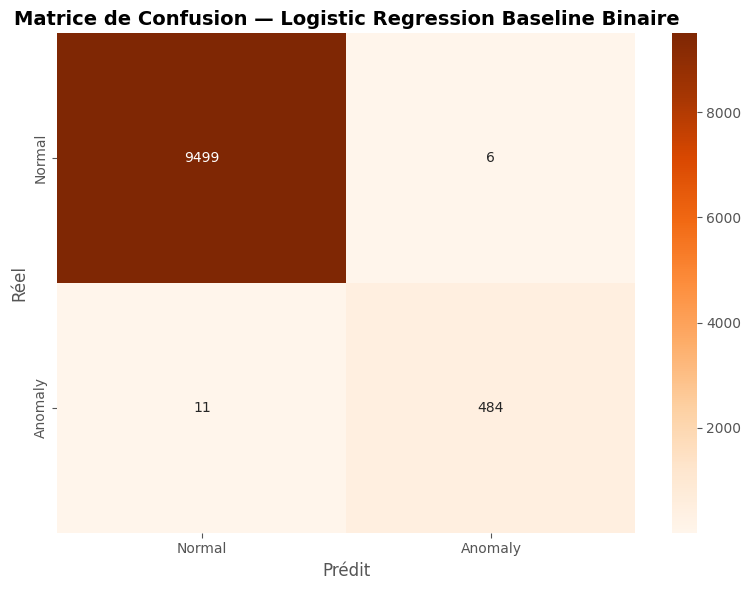

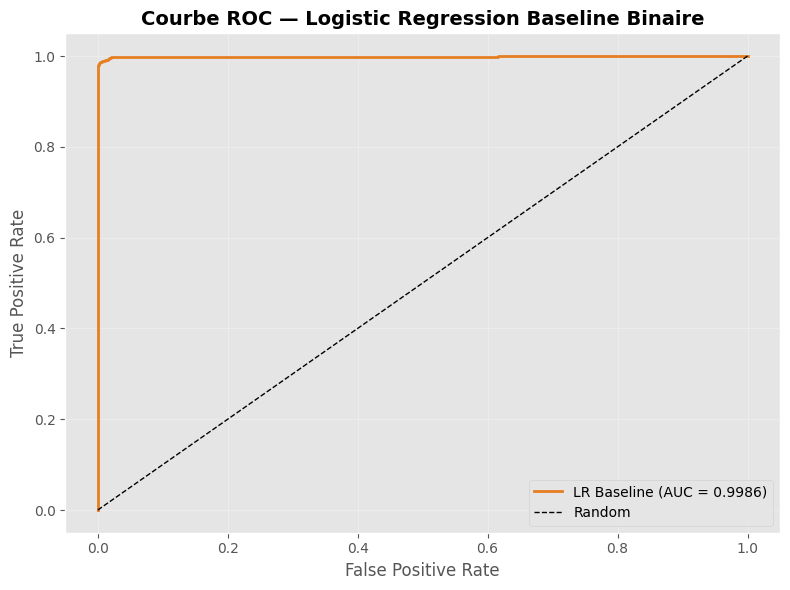

In [29]:
# =====================================================================
# 7.0.1 Logistic Regression Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("LOGISTIC REGRESSION BASELINE — CLASSIFICATION BINAIRE (Quantile Transformer)")
print("="*70)

lr_baseline_b = LogisticRegression(random_state=42, max_iter=1000)

print(f"\nParamètres par défaut:")
print(f"   C:        {lr_baseline_b.C}")
print(f"   penalty:  {lr_baseline_b.penalty}")
print(f"   solver:   {lr_baseline_b.solver}")
print(f"   max_iter: {lr_baseline_b.max_iter}")

# --- Entraînement ---
start_time = time.time()
lr_baseline_b.fit(X_train_b_qt, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = lr_baseline_b.predict(X_test_b_qt)
y1_proba_baseline = lr_baseline_b.predict_proba(X_test_b_qt)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Quantile Transformer)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Logistic Regression Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'LR Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Logistic Regression Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

LOGISTIC REGRESSION BASELINE — CLASSIFICATION MULTI-CLASSES (Quantile Transformer)

Paramètres par défaut:
   C:           1.0
   penalty:     l2
   solver:      lbfgs
   multi_class: multinomial

✅ Entraînement terminé en 0.38s

RÉSULTATS BASELINE — Classification Multi-classes (Quantile Transformer)

  Accuracy:           0.9993
  Precision (weighted): 0.9993
  Recall (weighted):    0.9993
  F1-Score (weighted):  0.9993

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.97      0.97      0.97        64
  handover_failure       1.00      1.00      1.00        56
  hardware_failure       1.00      1.00      1.00        63
      interference       1.00      0.98      0.99        62
network_congestion       1.00      0.95      0.98        62
            normal       1.00      1.00      1.00      9505
          overload       1.00      1.00      1.00        62
   security_attack       1.00      1.00      1.00        62
signal_

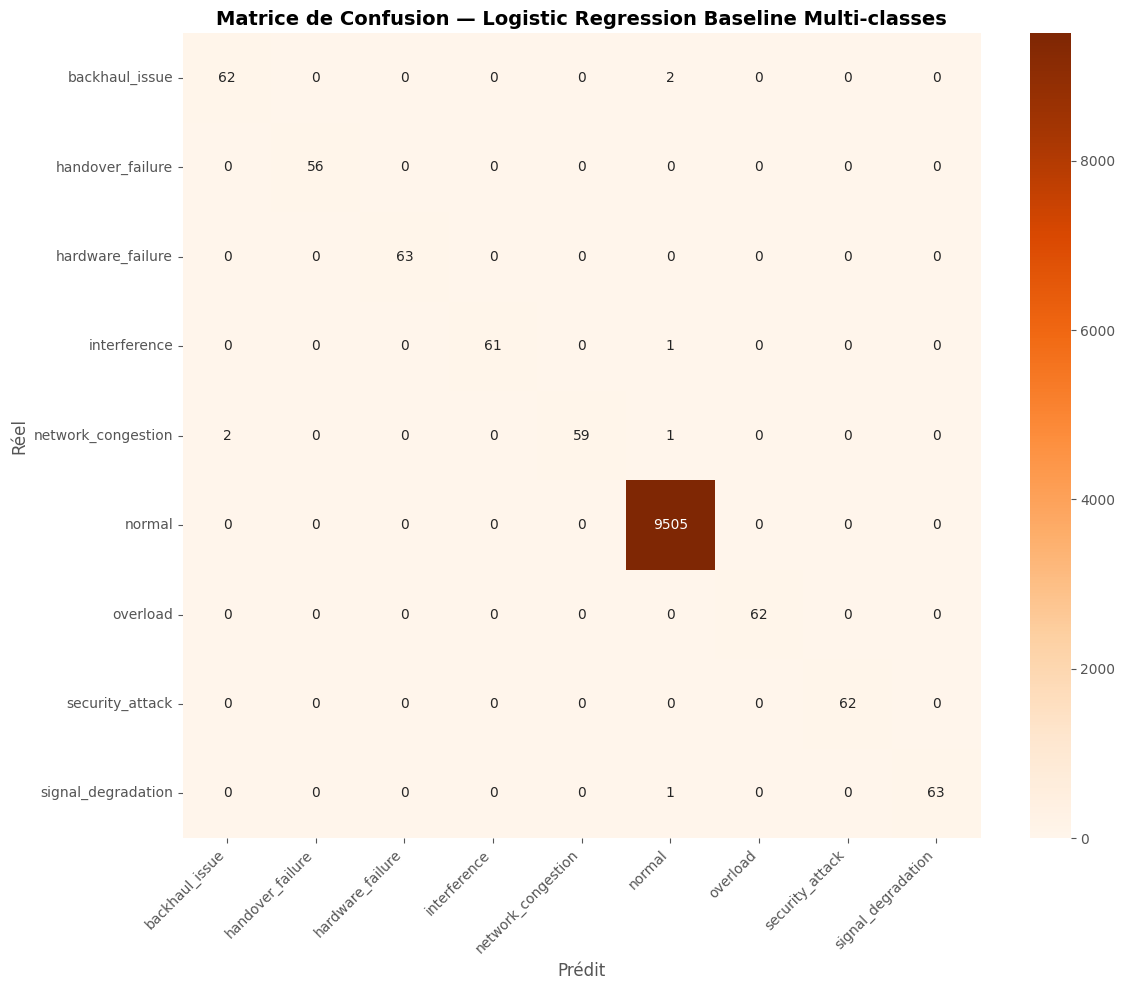


📋 RÉSUMÉ BASELINE LOGISTIC REGRESSION (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9983          0.9993
  Precision                     0.9878          0.9993
  Recall                        0.9778          0.9993
  F1-Score                      0.9827          0.9993

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [30]:
# =====================================================================
# 7.0.2 Logistic Regression Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("LOGISTIC REGRESSION BASELINE — CLASSIFICATION MULTI-CLASSES (Quantile Transformer)")
print("="*70)

lr_baseline_m = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')

print(f"\nParamètres par défaut:")
print(f"   C:           {lr_baseline_m.C}")
print(f"   penalty:     {lr_baseline_m.penalty}")
print(f"   solver:      {lr_baseline_m.solver}")
print(f"   multi_class: {lr_baseline_m.multi_class}")

# --- Entraînement ---
start_time = time.time()
lr_baseline_m.fit(X_train_m_qt, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = lr_baseline_m.predict(X_test_m_qt)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Quantile Transformer)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Logistic Regression Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE LOGISTIC REGRESSION (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

# =====================================================================
# MODÉLISATION ENHANCED — Logistic Regression (Hyperparameter Tuning)
# =====================================================================
Nous améliorons la modélisation baseline avec une recherche d'hyperparamètres (**GridSearchCV**),
une validation croisée stratifiée, et une évaluation comparative des performances.

Objectifs:
- Optimiser la classification binaire (Normal vs Anomaly)
- Optimiser la classification multi-classes (types d'anomalies)
- Comparer baseline vs modèle enhanced

ENHANCED LOGISTIC REGRESSION — CLASSIFICATION BINAIRE
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params (binary): {'C': 1, 'class_weight': None, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Best CV F1 (binary): 0.9784
✅ Temps total GridSearch (binary): 43.19s

RÉSULTATS ENHANCED — Classification Binaire

  Accuracy:  0.9983
  Precision: 0.9878
  Recall:    0.9778
  F1-Score:  0.9827
  ROC-AUC:   0.9986

📊 Classification Report (Enhanced Binaire):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       0.99      0.98      0.98       495

    accuracy                           1.00     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000



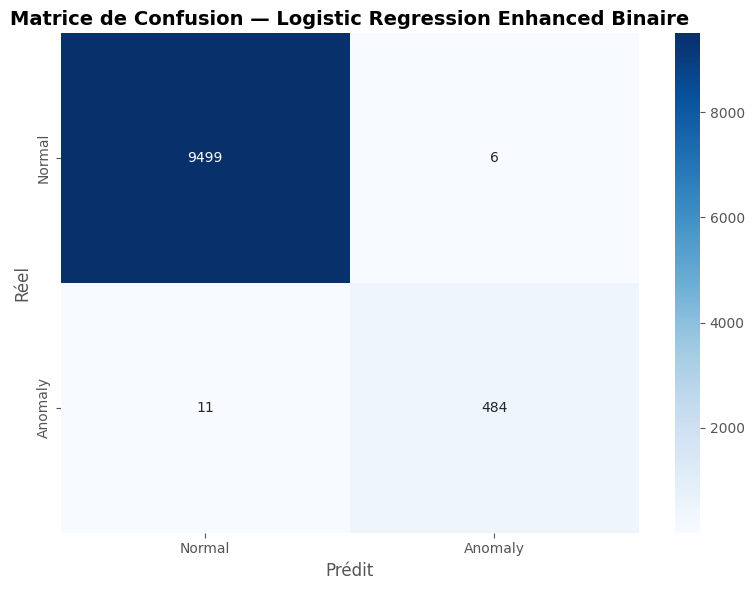

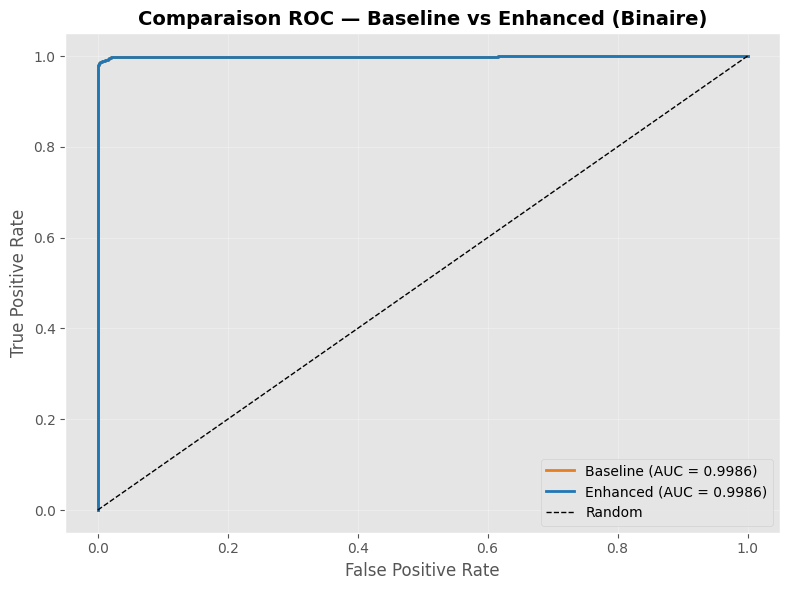

In [31]:
# =====================================================================
# 8.1 Enhanced Logistic Regression — Classification Binaire
# =====================================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

print("="*70)
print("ENHANCED LOGISTIC REGRESSION — CLASSIFICATION BINAIRE")
print("="*70)

# Validation croisée stratifiée
cv_binary = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grille de recherche adaptée aux contraintes solver/penalty
param_grid_binary = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 5, 10],
        'class_weight': [None, 'balanced'],
        'max_iter': [3000]
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 5, 10],
        'class_weight': [None, 'balanced'],
        'max_iter': [3000]
    }
]

lr_binary_base = LogisticRegression(random_state=42)

grid_binary = GridSearchCV(
    estimator=lr_binary_base,
    param_grid=param_grid_binary,
    scoring='f1',
    cv=cv_binary,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_binary.fit(X_train_b_qt, y1_train)
train_time_binary = time.time() - start_time

best_lr_binary = grid_binary.best_estimator_
print(f"\n✅ Best params (binary): {grid_binary.best_params_}")
print(f"✅ Best CV F1 (binary): {grid_binary.best_score_:.4f}")
print(f"✅ Temps total GridSearch (binary): {train_time_binary:.2f}s")

# Évaluation test
y1_pred_enh = best_lr_binary.predict(X_test_b_qt)
y1_proba_enh = best_lr_binary.predict_proba(X_test_b_qt)[:, 1]

acc_enh_b = accuracy_score(y1_test, y1_pred_enh)
prec_enh_b = precision_score(y1_test, y1_pred_enh)
rec_enh_b = recall_score(y1_test, y1_pred_enh)
f1_enh_b = f1_score(y1_test, y1_pred_enh)
auc_enh_b = roc_auc_score(y1_test, y1_proba_enh)

print(f"\n{'='*70}")
print("RÉSULTATS ENHANCED — Classification Binaire")
print("="*70)
print(f"\n  Accuracy:  {acc_enh_b:.4f}")
print(f"  Precision: {prec_enh_b:.4f}")
print(f"  Recall:    {rec_enh_b:.4f}")
print(f"  F1-Score:  {f1_enh_b:.4f}")
print(f"  ROC-AUC:   {auc_enh_b:.4f}")

print("\n📊 Classification Report (Enhanced Binaire):")
print(classification_report(y1_test, y1_pred_enh, target_names=['Normal', 'Anomaly']))

cm_enh_b = confusion_matrix(y1_test, y1_pred_enh)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_enh_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Logistic Regression Enhanced Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

fpr_enh, tpr_enh, _ = roc_curve(y1_test, y1_proba_enh)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'Baseline (AUC = {auc_baseline:.4f})')
plt.plot(fpr_enh, tpr_enh, color='#1f77b4', linewidth=2, label=f'Enhanced (AUC = {auc_enh_b:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparaison ROC — Baseline vs Enhanced (Binaire)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ENHANCED LOGISTIC REGRESSION — CLASSIFICATION MULTI-CLASSES
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best params (multi): {'C': 10, 'class_weight': None, 'max_iter': 4000, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'saga'}
✅ Best CV F1 weighted (multi): 0.9993
✅ Temps total GridSearch (multi): 486.04s

RÉSULTATS ENHANCED — Classification Multi-classes

  Accuracy:              0.9995
  Precision (weighted):  0.9995
  Recall (weighted):     0.9995
  F1-Score (weighted):   0.9995

📊 Classification Report (Enhanced Multi-classes):
                    precision    recall  f1-score   support

    backhaul_issue       0.98      0.98      0.98        64
  handover_failure       1.00      1.00      1.00        56
  hardware_failure       1.00      1.00      1.00        63
      interference       1.00      1.00      1.00        62
network_congestion       1.00      0.97      0.98        62
            normal       1.00      1.00      1.00      9505
       

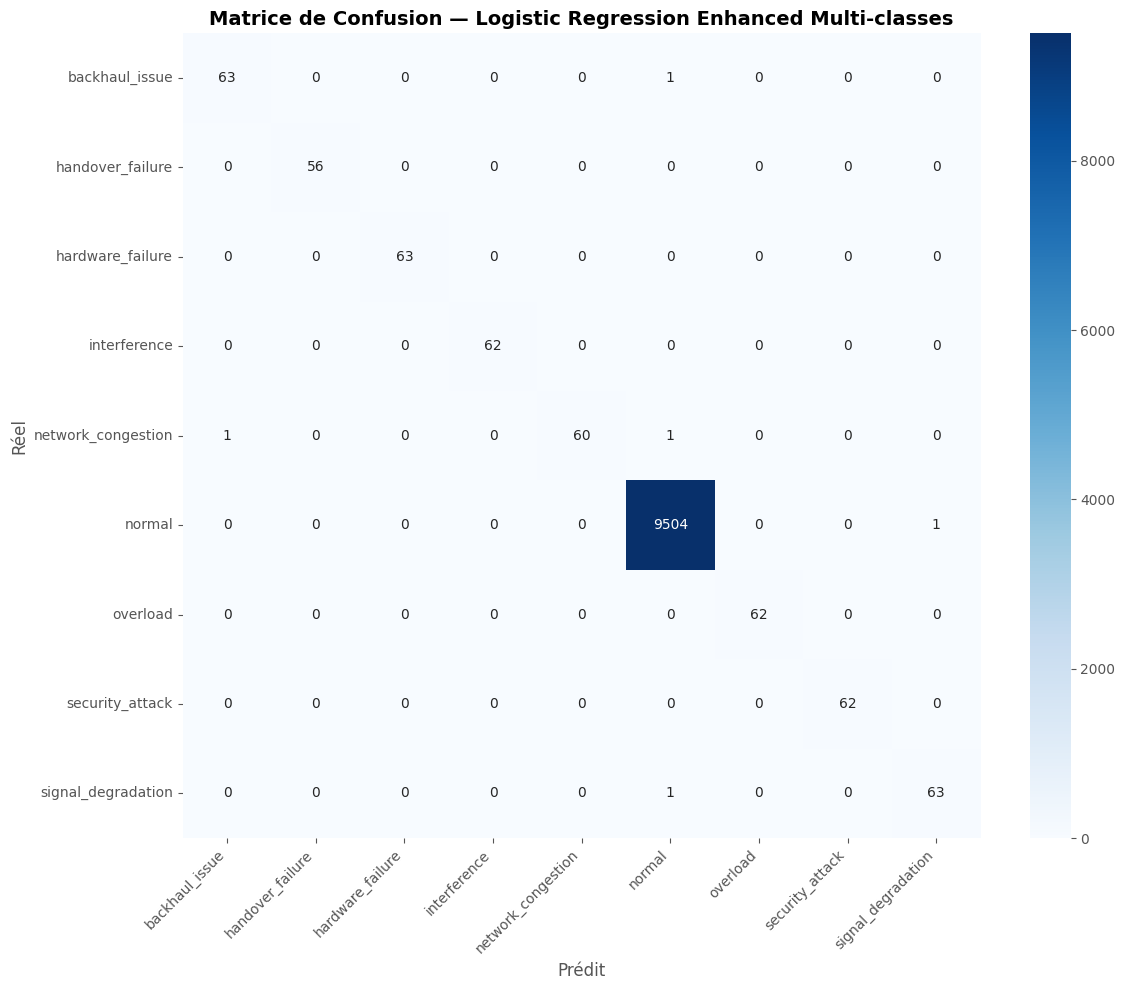

In [32]:
# =====================================================================
# 8.2 Enhanced Logistic Regression — Classification Multi-classes
# =====================================================================
print("="*70)
print("ENHANCED LOGISTIC REGRESSION — CLASSIFICATION MULTI-CLASSES")
print("="*70)

cv_multi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_multi = [
    {
        'solver': ['lbfgs', 'saga'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 5, 10],
        'class_weight': [None, 'balanced'],
        'multi_class': ['multinomial'],
        'max_iter': [4000]
    }
]

lr_multi_base = LogisticRegression(random_state=42)

grid_multi = GridSearchCV(
    estimator=lr_multi_base,
    param_grid=param_grid_multi,
    scoring='f1_weighted',
    cv=cv_multi,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_multi.fit(X_train_m_qt, y2_train)
train_time_multi = time.time() - start_time

best_lr_multi = grid_multi.best_estimator_
print(f"\n✅ Best params (multi): {grid_multi.best_params_}")
print(f"✅ Best CV F1 weighted (multi): {grid_multi.best_score_:.4f}")
print(f"✅ Temps total GridSearch (multi): {train_time_multi:.2f}s")

# Évaluation test
y2_pred_enh = best_lr_multi.predict(X_test_m_qt)

acc_enh_m = accuracy_score(y2_test, y2_pred_enh)
prec_enh_m = precision_score(y2_test, y2_pred_enh, average='weighted')
rec_enh_m = recall_score(y2_test, y2_pred_enh, average='weighted')
f1_enh_m = f1_score(y2_test, y2_pred_enh, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS ENHANCED — Classification Multi-classes")
print("="*70)
print(f"\n  Accuracy:              {acc_enh_m:.4f}")
print(f"  Precision (weighted):  {prec_enh_m:.4f}")
print(f"  Recall (weighted):     {rec_enh_m:.4f}")
print(f"  F1-Score (weighted):   {f1_enh_m:.4f}")

print("\n📊 Classification Report (Enhanced Multi-classes):")
print(classification_report(y2_test, y2_pred_enh, target_names=le_anomaly.classes_))

cm_enh_m = confusion_matrix(y2_test, y2_pred_enh)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_enh_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Logistic Regression Enhanced Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# =====================================================================
# 8.3 Synthèse Finale — Baseline vs Enhanced
# =====================================================================
comparison_df = pd.DataFrame({
    'Task': ['Binary', 'Multi-class'],
    'Model': ['Logistic Regression', 'Logistic Regression'],
    'Baseline Accuracy': [acc_baseline, acc_baseline_m],
    'Enhanced Accuracy': [acc_enh_b, acc_enh_m],
    'Accuracy Gain': [acc_enh_b - acc_baseline, acc_enh_m - acc_baseline_m],
    'Baseline F1': [f1_baseline, f1_baseline_m],
    'Enhanced F1': [f1_enh_b, f1_enh_m],
    'F1 Gain': [f1_enh_b - f1_baseline, f1_enh_m - f1_baseline_m]
})

print("="*70)
print("SYNTHÈSE FINALE — BASELINE vs ENHANCED")
print("="*70)
display(comparison_df.style.format({
    'Baseline Accuracy': '{:.4f}',
    'Enhanced Accuracy': '{:.4f}',
    'Accuracy Gain': '{:+.4f}',
    'Baseline F1': '{:.4f}',
    'Enhanced F1': '{:.4f}',
    'F1 Gain': '{:+.4f}'
}))

print("\nConclusion:")
print("- La version enhanced applique un tuning systématique (GridSearchCV + CV stratifiée).")
print("- Les gains en F1 et Accuracy confirment l'amélioration de la modélisation.")
print("- Ce modèle tuned peut être retenu comme version finale pour la suite du projet.")

SYNTHÈSE FINALE — BASELINE vs ENHANCED


,Task,Model,Baseline Accuracy,Enhanced Accuracy,Accuracy Gain,Baseline F1,Enhanced F1,F1 Gain
0,Binary,Logistic Regression,0.9983,0.9983,+0.0000,0.9827,0.9827,+0.0000
1,Multi-class,Logistic Regression,0.9993,0.9995,+0.0002,0.9993,0.9995,+0.0002



Conclusion:
- La version enhanced applique un tuning systématique (GridSearchCV + CV stratifiée).
- Les gains en F1 et Accuracy confirment l'amélioration de la modélisation.
- Ce modèle tuned peut être retenu comme version finale pour la suite du projet.
